# chapter 3: Question 8 using simple linear regression model

In [19]:
import numpy as np # ( 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import statsmodels.api as sm # fitting regression , helps to coefficients ,R^2 , p-values , cI, PI , diagnostic plots

In [20]:
Auto=pd.read_csv("C:\\Users\\Gahigi\\Downloads\\Auto.csv")

In [21]:
Auto
# 1 gallon is approximately 3.8 liters 
# mpg : Miles per gallon 30miles per gallon  : a car travel 30 miles using 1 gallon or using 4 liters of petrol 
# Higher mpg means high efficiency of car engine . mpg 100 

## Horsepower : hp ( Measure of engine / strength of the engine .


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [22]:
Auto['horsepower'].isnull().sum()

np.int64(0)

In [23]:
# Converting horsepower to numeric , when some values are ? or uknown set them as Nan)
Auto['horsepower']=pd.to_numeric(Auto['horsepower'],errors="coerce")

In [24]:
#Auto['horsepower'] 
# Drop Nan Values in mpg and Horsepower
cleaned_Auto=Auto.dropna(subset=['mpg','horsepower'])

In [25]:
cleaned_Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


# (a) Fit simple linear regression: mpg ~ horsepower using  :sm.OLS(y,X).fit() function and summary() for results

In [26]:
# sm.OLS(y,X).fit() function in python is equivalent to lm() in R-programming 

X=sm.add_constant(cleaned_Auto['horsepower']) # python transforms data to look 
y=cleaned_Auto['mpg']
fitted_line=sm.OLS(y,X).fit() # simple linear regression 

In [27]:
# summary() function , i.e  fitted_line.summary() was used to print out results 
# Printing out the results using summary()
print(fitted_line.summary()) # summary() results 

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           7.03e-81
Time:                        19:40:37   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

# i) The p-value is almost zero (≈ 0) from our table prob(F-statistic) 7.03e^-81

## This confirms that there is relationship between predictor and response

# ii) It is significant relationship due to p-value is very small tending to be zero .

# iii) It is negative relationship  due to this coefficient of predictor, horsepower :-0.1578  which is negative .

# iv ) predicted mpg at horsepower =98 , 95% confidence intervals (CI) and Prediction intervals(PI)

In [31]:
pred_mpg = pd.DataFrame({"const":[1], "horsepower":[98]})
pred = fitted_line.get_prediction(pred_mpg)
print(pred.summary_frame(alpha=0.05))


        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      23.973079      24.961075     14.809396   

   obs_ci_upper  
0     34.124758  


In [97]:
# CONFIDENCE INTERVAL(for the mean mpg): We are 95% confident that the true average mpg for all cars with 98 horsepower lies between: 23.97 and 24.96 mpg
# SIMPLE MEANING : If we collected many cars with 98 horsepower, their average mpg would likely fall in this range

# 95% Prediction Interval (for one new car): If you pick one single car with 98 horsepower, its mpg is likely between: 14.81 and 34.12 mpg
#This interval is much wider because: 1. Individual cars vary a lot 
# 2. Not all cars with 98 hp have the same mp

"""For a car with 98 horsepower, the model predicts an average fuel efficiency of 24.47 mpg. 
The 95% confidence interval for the mean mpg at this horsepower level is [23.97, 24.96], 
indicating a fairly precise estimate of the average. 
However, the 95% prediction interval for an individual car’s mpg is much wider, ranging from 14.81 to 34.12 mpg, 
reflecting substantial variability among cars with the same horsepower"""


'For a car with 98 horsepower, the model predicts an average fuel efficiency of 24.47 mpg. \nThe 95% confidence interval for the mean mpg at this horsepower level is [23.97, 24.96], \nindicating a fairly precise estimate of the average. \nHowever, the 95% prediction interval for an individual car’s mpg is much wider, ranging from 14.81 to 34.12 mpg, \nreflecting substantial variability among cars with the same horsepower'

# b) Plot of response and the predictor

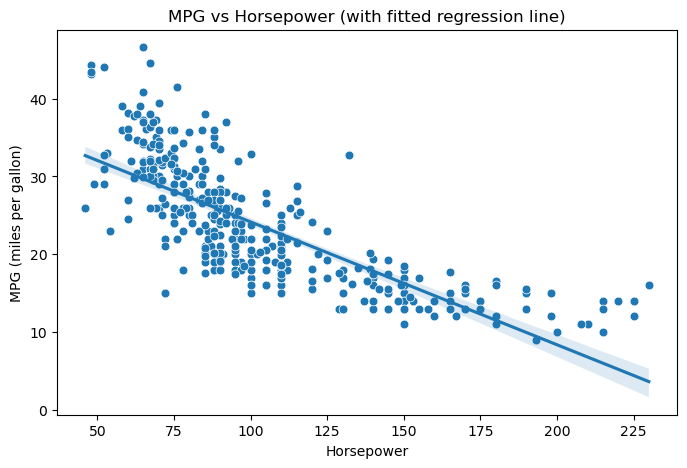

In [32]:
# Scatter plot + regression line
plt.figure(figsize=(8, 5))
sns.scatterplot(data=Auto, x="horsepower", y="mpg", s=40)
sns.regplot(data=Auto, x="horsepower", y="mpg", scatter=False)  # line only
plt.title("MPG vs Horsepower (with fitted regression line)")
plt.xlabel("Horsepower")
plt.ylabel("MPG (miles per gallon)")
plt.show()

In [33]:
"""The scatter plot of mpg versus horsepower shows a clear downward trend, indicating a strong negative relationship between engine power and fuel efficiency. The fitted regression line slopes from the upper left to the lower right, confirming that cars with higher horsepower tend to have lower mpg. Although the linear model captures the overall trend well, some dispersion of points around the line suggests that factors other than horsepower also influence mpg, and the relationship may not be perfectly linear"""

'The scatter plot of mpg versus horsepower shows a clear downward trend, indicating a strong negative relationship between engine power and fuel efficiency. The fitted regression line slopes from the upper left to the lower right, confirming that cars with higher horsepower tend to have lower mpg. Although the linear model captures the overall trend well, some dispersion of points around the line suggests that factors other than horsepower also influence mpg, and the relationship may not be perfectly linear'

In [34]:
"""When horsepower increases → mpg decreases

When horsepower decreases → mpg increases"""


'When horsepower increases → mpg decreases\n\nWhen horsepower decreases → mpg increases'

In [35]:
"""In brief, More powerful cars are less fuel efficient."""

'In brief, More powerful cars are less fuel efficient.'

## c) Diagnostic plots (check if regression assumptions look OK)
### Residuals vs Fitted (linearity / patterns)

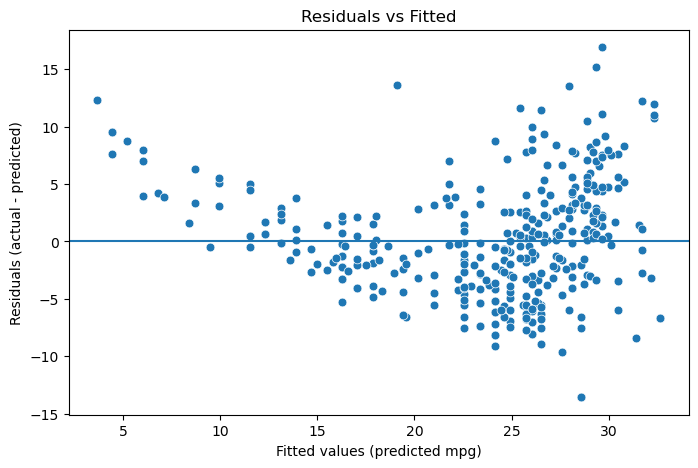

In [108]:
fitted = model.fittedvalues
resid = model.resid

plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted, y=resid, s=40)
plt.axhline(0)
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values (predicted mpg)")
plt.ylabel("Residuals (actual - predicted)")
plt.show()


<Figure size 600x600 with 0 Axes>

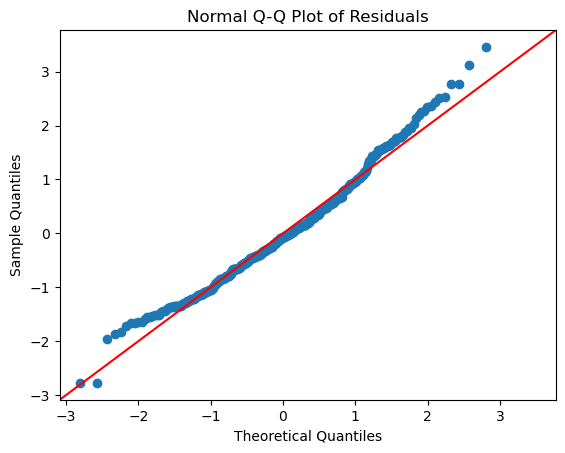

In [109]:
import statsmodels.api as sm

plt.figure(figsize=(6,6))
sm.qqplot(resid, line="45", fit=True)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()


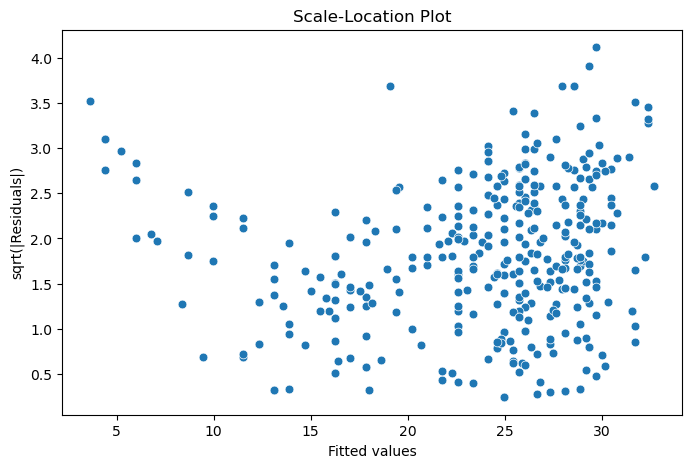

In [110]:
import numpy as np

sqrt_abs_resid = np.sqrt(np.abs(resid))

plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted, y=sqrt_abs_resid, s=40)
plt.title("Scale-Location Plot")
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|Residuals|)")
plt.show()


<Figure size 800x600 with 0 Axes>

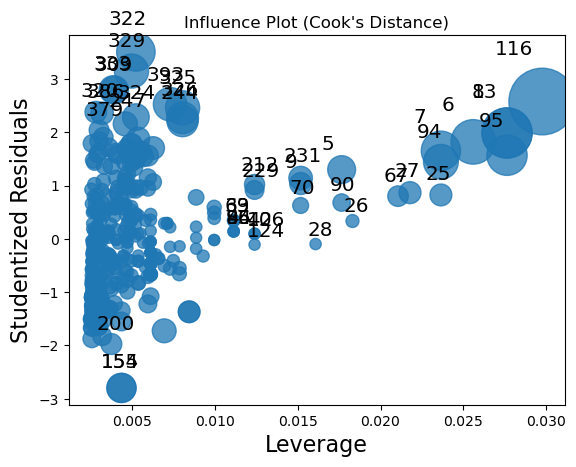

In [111]:
plt.figure(figsize=(8,6))
sm.graphics.influence_plot(model, criterion="cooks")
plt.title("Influence Plot (Cook's Distance)")
plt.show()


In [112]:
"""Diagnostic analysis suggests that the simple linear regression model captures the main negative relationship between horsepower and mpg, but with some limitations. 
The residuals are approximately normally distributed, supporting valid inference. However, the residuals vs fitted and scale-location plots reveal mild non-linearity and heteroscedasticity, and the influence plot shows a few potentially influential observations. 
Overall, the model is acceptable but could be improved using a nonlinear specification such as a quadratic term for horsepower"""

'Diagnostic analysis suggests that the simple linear regression model captures the main negative relationship between horsepower and mpg, but with some limitations. \nThe residuals are approximately normally distributed, supporting valid inference. However, the residuals vs fitted and scale-location plots reveal mild non-linearity and heteroscedasticity, and the influence plot shows a few potentially influential observations. \nOverall, the model is acceptable but could be improved using a nonlinear specification such as a quadratic term for horsepower'